In [5]:
import pandas as pd

df = pd.read_excel('df1.xlsx')
for col in df.columns:
    print(col)

id
brand
title
description
price
priceCurrency
cluster_id
url
title_description
model
model_number
product_type
chipset_name
vram_gb
storage_gb
read_speed_mb_s
write_speed_mb_s
bus_type
interface_type
width_mm
length_mm
height_mm
weight_g
storage_connection_type
memory_type
color
form_factor


In [9]:
import pandas as pd
import numpy as np

# ── Load data ─────────────────────────────────────────────────────────────────
df1     = pd.read_json('normalized_products/dataset_1_normalized.json')
df2     = pd.read_json('normalized_products/dataset_2_normalized.json')
df3     = pd.read_json('normalized_products/dataset_3_normalized.json')
df4     = pd.read_json('normalized_products/dataset_4_normalized.json')
kb      = pd.concat([df2, df3, df4], ignore_index=True)

SKIP = {'cluster_id', 'id', 'url', 'price', 'priceCurrency'}
attrs = [c for c in df1.columns if c not in SKIP]

# ── Count nulls in Dataset 1 ──────────────────────────────────────────────────
results = []
for attr in attrs:
    total      = len(df1)
    null_count = df1[attr].isna().sum()
    null_pct   = null_count / total * 100

    # How many of those nulls can be filled from KB via cluster_id?
    retrievable = 0
    for _, row in df1[df1[attr].isna()].iterrows():
        cluster_id = row.get('cluster_id')
        if pd.isna(cluster_id):
            continue
        kb_matches = kb[kb['cluster_id'] == cluster_id]
        found = any(
            pd.notna(r.get(attr)) and
            str(r.get(attr)).strip().lower() not in {'', 'none', 'nan'}
            for _, r in kb_matches.iterrows()
        )
        if found:
            retrievable += 1

    results.append({
        'attribute':        attr,
        'total':            total,
        'filled':           total - null_count,
        'null_count':       null_count,
        'retrievable':      retrievable,
        'not_retrievable':  null_count - retrievable
    })

summary = pd.DataFrame(results).sort_values('null_count', ascending=False)
summary = summary[summary['null_count'] > 0]  # only show attrs with nulls

print(f'Dataset 1: {len(df1)} rows\n')
print(summary[['attribute','total','filled','null_count','retrievable','not_retrievable']].to_string(index=False))
print(f'\nTotal null values across all attributes: {summary["null_count"].sum()}')
print(f'Total retrievable from KB:               {summary["retrievable"].sum()}')
print(f'Total not retrievable:                   {summary["not_retrievable"].sum()}')
print(f'Overall retrievability rate:             {summary["retrievable"].sum()/summary["null_count"].sum()*100:.1f}%')

# Save for Flourish / Datawrapper
summary.to_csv('results/null_analysis.csv', index=False)
print('\n✓ Saved to results/null_analysis.csv')

Dataset 1: 812 rows

              attribute  total  filled  null_count  retrievable  not_retrievable
               weight_g    812      26         786           62              724
               width_mm    812      45         767           84              683
              length_mm    812      45         767           78              689
              height_mm    812      46         766          101              665
                  color    812     120         692           64              628
       write_speed_mb_s    812     122         690           87              603
        read_speed_mb_s    812     151         661          122              539
            memory_type    812     210         602           43              559
                vram_gb    812     229         583            2              581
           chipset_name    812     231         581            0              581
           model_number    812     334         478          302              176
storage

In [10]:
import pandas as pd

# Load your null analysis
summary = pd.read_csv('results/null_analysis.csv')

# Flourish Sankey needs 3 columns: source, target, value
sankey_rows = []

for _, row in summary.iterrows():
    attr = row['attribute']

    # Layer 1: Dataset 1 total → attribute
    sankey_rows.append({
        'source': 'Dataset 1\n(812 products)',
        'target': attr,
        'value':  row['total']
    })

    # Layer 2a: attribute → already filled
    if row['filled'] > 0:
        sankey_rows.append({
            'source': attr,
            'target': 'Already filled\nin Dataset 1',
            'value':  row['filled']
        })

    # Layer 2b: attribute → null (missing)
    if row['null_count'] > 0:
        sankey_rows.append({
            'source': attr,
            'target': f'{attr}\n(missing)',
            'value':  row['null_count']
        })

    # Layer 3a: missing → retrievable from KB
    if row['retrievable'] > 0:
        sankey_rows.append({
            'source': f'{attr}\n(missing)',
            'target': 'Retrievable\nfrom KB ✓',
            'value':  row['retrievable']
        })

    # Layer 3b: missing → not retrievable
    if row['not_retrievable'] > 0:
        sankey_rows.append({
            'source': f'{attr}\n(missing)',
            'target': 'Not retrievable\nfrom KB ✗',
            'value':  row['not_retrievable']
        })

sankey_df = pd.DataFrame(sankey_rows)
sankey_df.to_csv('results/sankey_data.csv', index=False)
print(f'✓ Saved to results/sankey_data.csv')
print(f'  {len(sankey_df)} flow rows')
print(sankey_df.head(10).to_string(index=False))

✓ Saved to results/sankey_data.csv
  89 flow rows
                   source                       target  value
Dataset 1\n(812 products)                     weight_g    812
                 weight_g Already filled\nin Dataset 1     26
                 weight_g          weight_g\n(missing)    786
      weight_g\n(missing)       Retrievable\nfrom KB ✓     62
      weight_g\n(missing)   Not retrievable\nfrom KB ✗    724
Dataset 1\n(812 products)                     width_mm    812
                 width_mm Already filled\nin Dataset 1     45
                 width_mm          width_mm\n(missing)    767
      width_mm\n(missing)       Retrievable\nfrom KB ✓     84
      width_mm\n(missing)   Not retrievable\nfrom KB ✗    683


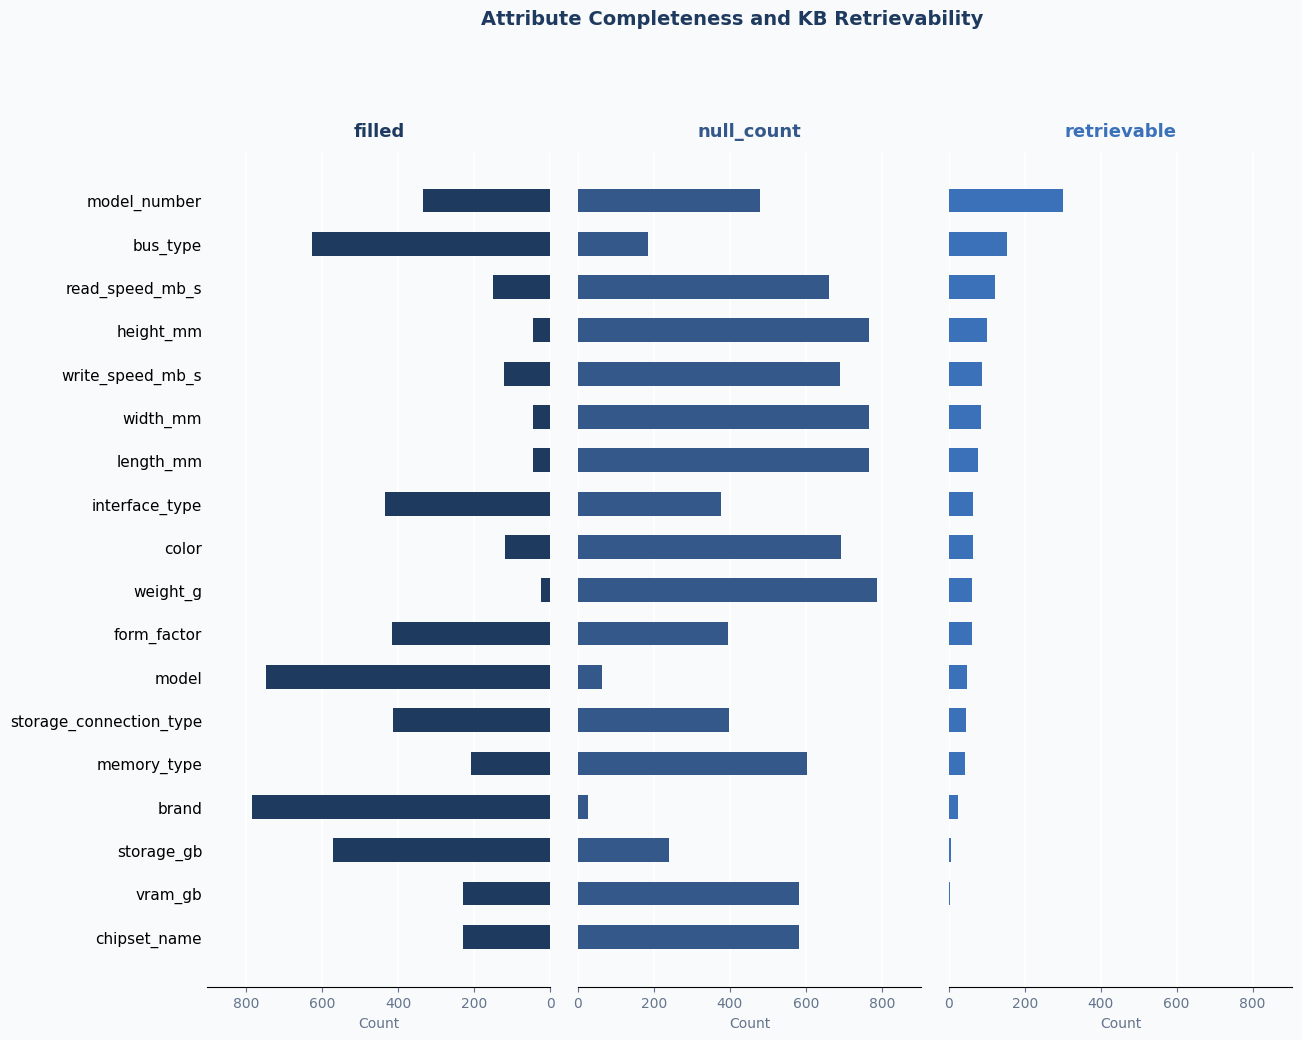

✓ figures/null_analysis_panels.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load data
summary = pd.read_csv('results/null_analysis.csv')

# Filter to meaningful attributes and sort by null_count descending
TARGET = ['bus_type','model','model_number','read_speed_mb_s',
          'write_speed_mb_s','height_mm','width_mm']

# Use all attrs or just target — comment/uncomment as needed
# summary = summary[summary['attribute'].isin(TARGET)]
summary = summary.sort_values('retrievable', ascending=True)  # ascending for horizontal bars

attrs  = summary['attribute'].tolist()
filled = summary['filled'].tolist()
nulls  = summary['null_count'].tolist()
retrvb = summary['retrievable'].tolist()

n = len(attrs)
y = range(n)
BAR_H = 0.55

# ── Colors ────────────────────────────────────────────────────────────────────
C_FILLED = '#1E3A5F'   # dark navy  — already filled
C_NULL   = "#335889"   # teal blue  — null count
C_RETR   = "#3A71B9"   # purple     — retrievable (matches your screenshot)

fig = plt.figure(figsize=(14, max(6, n * 0.52 + 1.5)))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel 1: Filled ───────────────────────────────────────────────────────────
ax1.barh(y, filled, height=BAR_H, color=C_FILLED, zorder=3)
ax1.set_yticks(y)
ax1.set_yticklabels(attrs, fontsize=11)
ax1.set_xlabel('Count', fontsize=10, color='#64748B')
ax1.set_title('filled', fontsize=13, fontweight='bold', color=C_FILLED, pad=10)
ax1.invert_xaxis()  # flip so bars grow leftward like the screenshot
ax1.spines[['top','right','left']].set_visible(False)
ax1.tick_params(axis='y', length=0)
ax1.tick_params(axis='x', colors='#64748B')
ax1.set_facecolor('#F8FAFC')
ax1.grid(axis='x', color='white', linewidth=1.5, zorder=0)
ax1.set_xlim(max(filled)*1.15, 0)

# ── Panel 2: Null count ───────────────────────────────────────────────────────
ax2.barh(y, nulls, height=BAR_H, color=C_NULL, zorder=3)
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel('Count', fontsize=10, color='#64748B')
ax2.set_title('null_count', fontsize=13, fontweight='bold', color=C_NULL, pad=10)
ax2.spines[['top','right','left']].set_visible(False)
ax2.tick_params(axis='y', length=0)
ax2.tick_params(axis='x', colors='#64748B')
ax2.set_facecolor('#F8FAFC')
ax2.grid(axis='x', color='white', linewidth=1.5, zorder=0)
ax2.set_xlim(0, max(nulls)*1.15)

# ── Panel 3: Retrievable ──────────────────────────────────────────────────────
ax3.barh(y, retrvb, height=BAR_H, color=C_RETR, zorder=3)
ax3.set_yticks(y)
ax3.set_yticklabels([])
ax3.set_xlabel('Count', fontsize=10, color='#64748B')
ax3.set_title('retrievable', fontsize=13, fontweight='bold', color=C_RETR, pad=10)
ax3.spines[['top','right','left']].set_visible(False)
ax3.tick_params(axis='y', length=0)
ax3.tick_params(axis='x', colors='#64748B')
ax3.set_facecolor('#F8FAFC')
ax3.grid(axis='x', color='white', linewidth=1.5, zorder=0)
ax3.set_xlim(0, max(nulls)*1.15)  # same scale as null panel for easy comparison

fig.patch.set_facecolor('#F8FAFC')
plt.suptitle('Attribute Completeness and KB Retrievability',
             fontsize=14, fontweight='bold', color='#1E3A5F', y=1.01)

plt.savefig('figures/null_analysis_panels.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('✓ figures/null_analysis_panels.png')

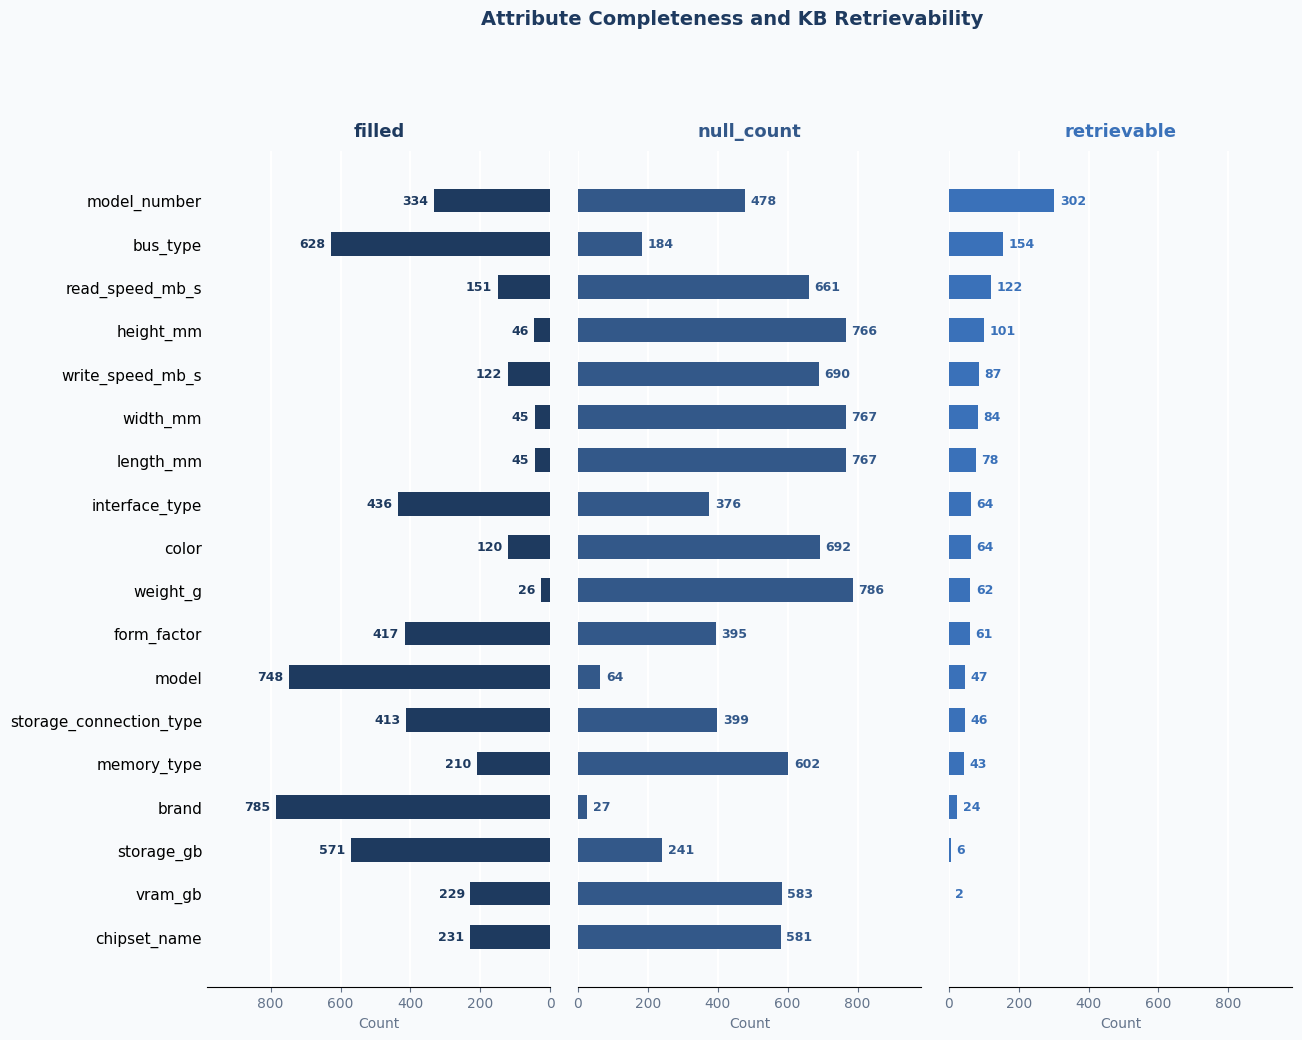

✓ figures/null_analysis_panels.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load data
summary = pd.read_csv('results/null_analysis.csv')

TARGET = ['bus_type','model','model_number','read_speed_mb_s',
          'write_speed_mb_s','height_mm','width_mm']

# summary = summary[summary['attribute'].isin(TARGET)]  # uncomment for target only
summary = summary.sort_values('retrievable', ascending=True)

attrs  = summary['attribute'].tolist()
filled = summary['filled'].tolist()
nulls  = summary['null_count'].tolist()
retrvb = summary['retrievable'].tolist()

n = len(attrs)
y = range(n)
BAR_H = 0.55

C_FILLED = '#1E3A5F'
C_NULL   = '#335889'
C_RETR   = '#3A71B9'

fig = plt.figure(figsize=(14, max(6, n * 0.52 + 1.5)))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel 1: Filled ───────────────────────────────────────────────────────────
ax1.barh(y, filled, height=BAR_H, color=C_FILLED, zorder=3)
for i, v in enumerate(filled):
    if v > 0:
        ax1.text(v + max(filled)*0.02, i, str(v),
                 va='center', ha='right', fontsize=9, color=C_FILLED, fontweight='bold')
ax1.set_yticks(y)
ax1.set_yticklabels(attrs, fontsize=11)
ax1.set_xlabel('Count', fontsize=10, color='#64748B')
ax1.set_title('filled', fontsize=13, fontweight='bold', color=C_FILLED, pad=10)
ax1.invert_xaxis()
ax1.spines[['top','right','left']].set_visible(False)
ax1.tick_params(axis='y', length=0)
ax1.tick_params(axis='x', colors='#64748B')
ax1.set_facecolor('#F8FAFC')
ax1.grid(axis='x', color='white', linewidth=1.5, zorder=0)
ax1.set_xlim(max(filled)*1.25, 0)

# ── Panel 2: Null count ───────────────────────────────────────────────────────
ax2.barh(y, nulls, height=BAR_H, color=C_NULL, zorder=3)
for i, v in enumerate(nulls):
    if v > 0:
        ax2.text(v + max(nulls)*0.02, i, str(v),
                 va='center', ha='left', fontsize=9, color=C_NULL, fontweight='bold')
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel('Count', fontsize=10, color='#64748B')
ax2.set_title('null_count', fontsize=13, fontweight='bold', color=C_NULL, pad=10)
ax2.spines[['top','right','left']].set_visible(False)
ax2.tick_params(axis='y', length=0)
ax2.tick_params(axis='x', colors='#64748B')
ax2.set_facecolor('#F8FAFC')
ax2.grid(axis='x', color='white', linewidth=1.5, zorder=0)
ax2.set_xlim(0, max(nulls)*1.25)

# ── Panel 3: Retrievable ──────────────────────────────────────────────────────
ax3.barh(y, retrvb, height=BAR_H, color=C_RETR, zorder=3)
for i, v in enumerate(retrvb):
    if v > 0:
        ax3.text(v + max(nulls)*0.02, i, str(v),
                 va='center', ha='left', fontsize=9, color=C_RETR, fontweight='bold')
ax3.set_yticks(y)
ax3.set_yticklabels([])
ax3.set_xlabel('Count', fontsize=10, color='#64748B')
ax3.set_title('retrievable', fontsize=13, fontweight='bold', color=C_RETR, pad=10)
ax3.spines[['top','right','left']].set_visible(False)
ax3.tick_params(axis='y', length=0)
ax3.tick_params(axis='x', colors='#64748B')
ax3.set_facecolor('#F8FAFC')
ax3.grid(axis='x', color='white', linewidth=1.5, zorder=0)
ax3.set_xlim(0, max(nulls)*1.25)

fig.patch.set_facecolor('#F8FAFC')
plt.suptitle('Attribute Completeness and KB Retrievability',
             fontsize=14, fontweight='bold', color='#1E3A5F', y=1.01)

plt.savefig('figures/null_analysis_panels.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('✓ figures/null_analysis_panels.png')

In [23]:
import pandas as pd

df = pd.read_json("normalized_products/dataset_1_normalized.json")
filter = df[(df["cluster_id"] == 1856741) | (df["cluster_id"] == 827983) | (df["cluster_id"] == 49333) | (df["cluster_id"] == 2922429) | (df["cluster_id"] == 350379) | (df["cluster_id"] == 2796436)]
filter

,id,brand,title,description,price,priceCurrency,cluster_id,url,title_description,model,...,bus_type,interface_type,width_mm,length_mm,height_mm,weight_g,storage_connection_type,memory_type,color,form_factor
220,8333161,ADATA,ADATA SSD 256GB XPG SX8200 Pro PCIe Gen3x4 M.2...,XPG SX8200 Pro PCIe Gen3x4 M.2 2280 Solid Stat...,53.00,EUR,1856741,https://shop-it.vektra.sk/adata-ssd-256gb-xpg-...,ADATA SSD 256GB XPG SX8200 Pro PCIe Gen3x4 M.2...,XPG SX8200 Pro,...,PCIe 3.0 x4,NVMe,22.0,80.0,3.5,8.00,M.2,None,None,M.2 2280
371,10565065,Western Digital,WD Blue SN550 500 GB Solid State Drive - M.2 2...,General InformationManufacturer: Western Digit...,114.99,CAD,2796436,http://www.simcoeitsolutions.ca/product/wd-blu...,WD Blue SN550 500 GB Solid State Drive - M.2 2...,Blue SN550,...,PCIe 3.0 x4,NVMe,22.0,80.0,2.4,6.50,M.2,None,None,M.2 2280
393,15871125,Gigabyte,GIGABYTE 128GB M.2 NVMe,CAPACITY128 GBFORM FACTORM.2Features Form Fact...,3350.00,INR,2922429,https://www.pcstudio.in/product/gigabyte-128gb...,GIGABYTE 128GB M.2 NVMe. Description: CAPACITY...,GIGABYTE NVMe SSD,...,PCIe 3.0 x4,NVMe 1.3,22.0,80.0,2.3,NaN,M.2,None,None,M.2 2280
468,66823247,Samsung,SSD M.2 Samsung 970 Pro 1TB,BrandSAMSUNGSeries970 PROModelMZ-V7P1T0BWDevic...,2609.99,BRL,350379,https://www.performancesolutions.com.br/ssd-m....,SSD M.2 Samsung 970 Pro 1TB. Description: Bran...,970 PRO,...,PCIe 3.0 x4,NVMe,22.1,NaN,2.3,7.94,M.2,64L V-NAND MLC,None,M.2 2280
584,28532611,Crucial,CRUCIAL P2 250GB M.2 NVMe,CRUCIAL P2 250GB M.2 NVMe (CT250P2SSD8)Crucial...,4550.00,INR,49333,https://www.pcstudio.in/product/crucial-p2-250...,CRUCIAL P2 250GB M.2 NVMe. Description: CRUCIA...,P2,...,PCIe 3.0 x4,NVMe™,NaN,NaN,NaN,NaN,M.2,None,None,M.2
752,1088849,ADATA,ADATA SSD 512GB XPG SX8200 Pro PCIe Gen3x4 M.2...,XPG SX8200 Pro PCIe Gen3x4 M.2 2280 Solid Stat...,81.00,EUR,827983,https://shop-it.vektra.sk/adata-ssd-512gb-xpg-...,ADATA SSD 512GB XPG SX8200 Pro PCIe Gen3x4 M.2...,XPG SX8200 Pro,...,PCIe 3.0 x4,NVMe,22.0,80.0,3.5,8.00,M.2,None,None,M.2 2280
